In [6]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt

# since engineering values are a range not just dual class or binary ans


# I AM GOD
np.random.seed(42)
true_mu=30  # true mean concr str in mpa
true_sigma=4
cube_tests = np.random.normal(loc=true_mu, scale=true_sigma, size=50)

print(f"Sample Mean: {cube_tests.mean():.2f} MPa")
print(f"Sample Std:  {cube_tests.std():.2f} MPa")
# sample bias

Sample Mean: 29.10 MPa
Sample Std:  3.70 MPa


c:\Users\digit\miniconda3\envs\infra_quant\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [myu, sig]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


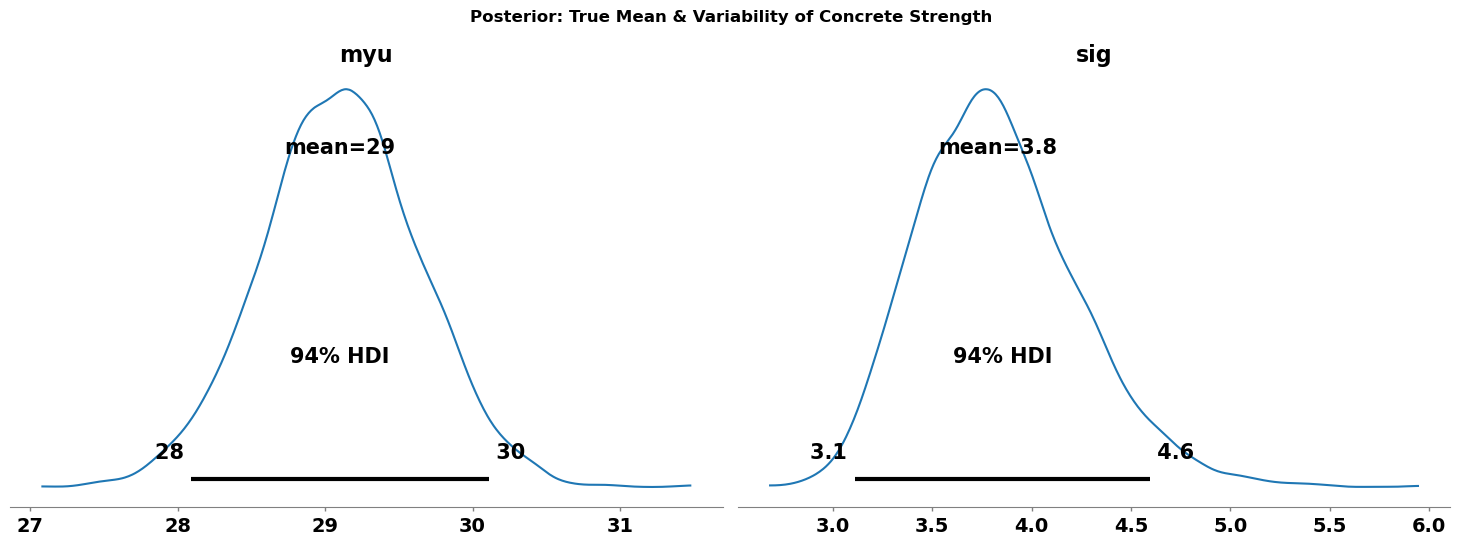

In [7]:
with pm.Model() as str_model:

    #what do we believe first?
    # mu: "Concrete strength is probably between 20 and 40 MPa"
    # sigma: "The variability is probably between 1 and 15 MPa"


    myu=pm.Normal("myu", mu=30, sigma=10)

    # half normal cuz variablitiy cannot be negative, should we use a diff distor?
    sig=pm.HalfNormal("sig", sigma=15)# is sigma value correct here?
    # why no mu? always 1?


    y= pm.Normal("y", mu=myu, sigma=sig, observed=cube_tests)
    trace=pm.sample(2000, tune=1000, )


    az.plot_posterior(trace, var_names=["myu", "sig"],
                 ref_val={"mu": [{"ref_val": true_mu}],
                           "sigma": [{"ref_val": true_sigma}]})
plt.suptitle("Posterior: True Mean & Variability of Concrete Strength")
plt.tight_layout()
plt.show()